# **House Price Prediction using Multiple Linear Regression**

## About Dataset
This dataset contains housing data with various features to predict house prices.

## Key Columns
- **price**: Target variable (House price in currency units)
- **area**: Area of the house in square feet
- **bedrooms**: Number of bedrooms
- **bathrooms**: Number of bathrooms
- **stories**: Number of stories
- **mainroad**: Access to main road (yes/no)
- **guestroom**: Guest room availability (yes/no)
- **basement**: Basement availability (yes/no)
- **hotwaterheating**: Hot water heating facility (yes/no)
- **airconditioning**: Air conditioning facility (yes/no)
- **parking**: Number of parking spaces
- **prefarea**: Preferred area (yes/no)
- **furnishingstatus**: Furnishing status (furnished/semi-furnished/unfurnished)

# Step 1: Importing Libraries and Loading Data

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error

# For VIF calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the dataset
df = pd.read_csv('/content/House_Pricing_MLR.csv')

# Display first 10 rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


# Step 2: Dataset Overview

Checking the structure, data types, and basic information about the dataset.

In [ ]:
# Check dataset shape
print("Dataset Shape:", df.shape)
print("\n" + "="*50 + "\n")

# Dataset information - data types and non-null counts
print("Dataset Information:")
df.info()
print("\n" + "="*50 + "\n")

# Check column names
print("Column Names:")
print(list(df.columns))

Dataset Shape: (545, 13)


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Column Names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement',

# Step 3: Descriptive Statistics

Univariate analysis to understand the distribution and statistical summary of numerical features.

In [ ]:
# Descriptive statistics for numerical columns
print("Descriptive Statistics (Numerical Columns):")
df.describe()

Descriptive Statistics (Numerical Columns):


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# Step 4: Data Quality Check

Checking for duplicate rows and missing values in the dataset.

In [ ]:
# Check for duplicate rows
print("Duplicate Rows Check:")
print(f"Total duplicate rows: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True, keep='last')
    df = df.reset_index(drop=True)
    print(f"After removing duplicates, shape: {df.shape}")
else:
    print("No duplicate entries found.")

print("\n" + "="*50 + "\n")

# Check for missing values
print("Missing Values Check:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Duplicate Rows Check:
Total duplicate rows: 0
No duplicate entries found.


Missing Values Check:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0


# Step 5: Unique Values Analysis

Understanding the cardinality of each feature and examining categorical variable categories.

In [ ]:
# Check unique values in each column
print("Unique Values Count per Column:")
print(df.nunique())
print("\n" + "="*50 + "\n")

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical Columns ({len(categorical_cols)}): {categorical_cols}")

print("\n" + "="*50 + "\n")

# Check unique values in categorical columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Unique Values Count per Column:
price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64


Numerical Columns (6): ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Columns (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


# Step 6: Exploratory Data Analysis (EDA)

## 6.1 Univariate Analysis - Distribution Plots

Visualizing the distribution of numerical features to understand their spread and identify any skewness.

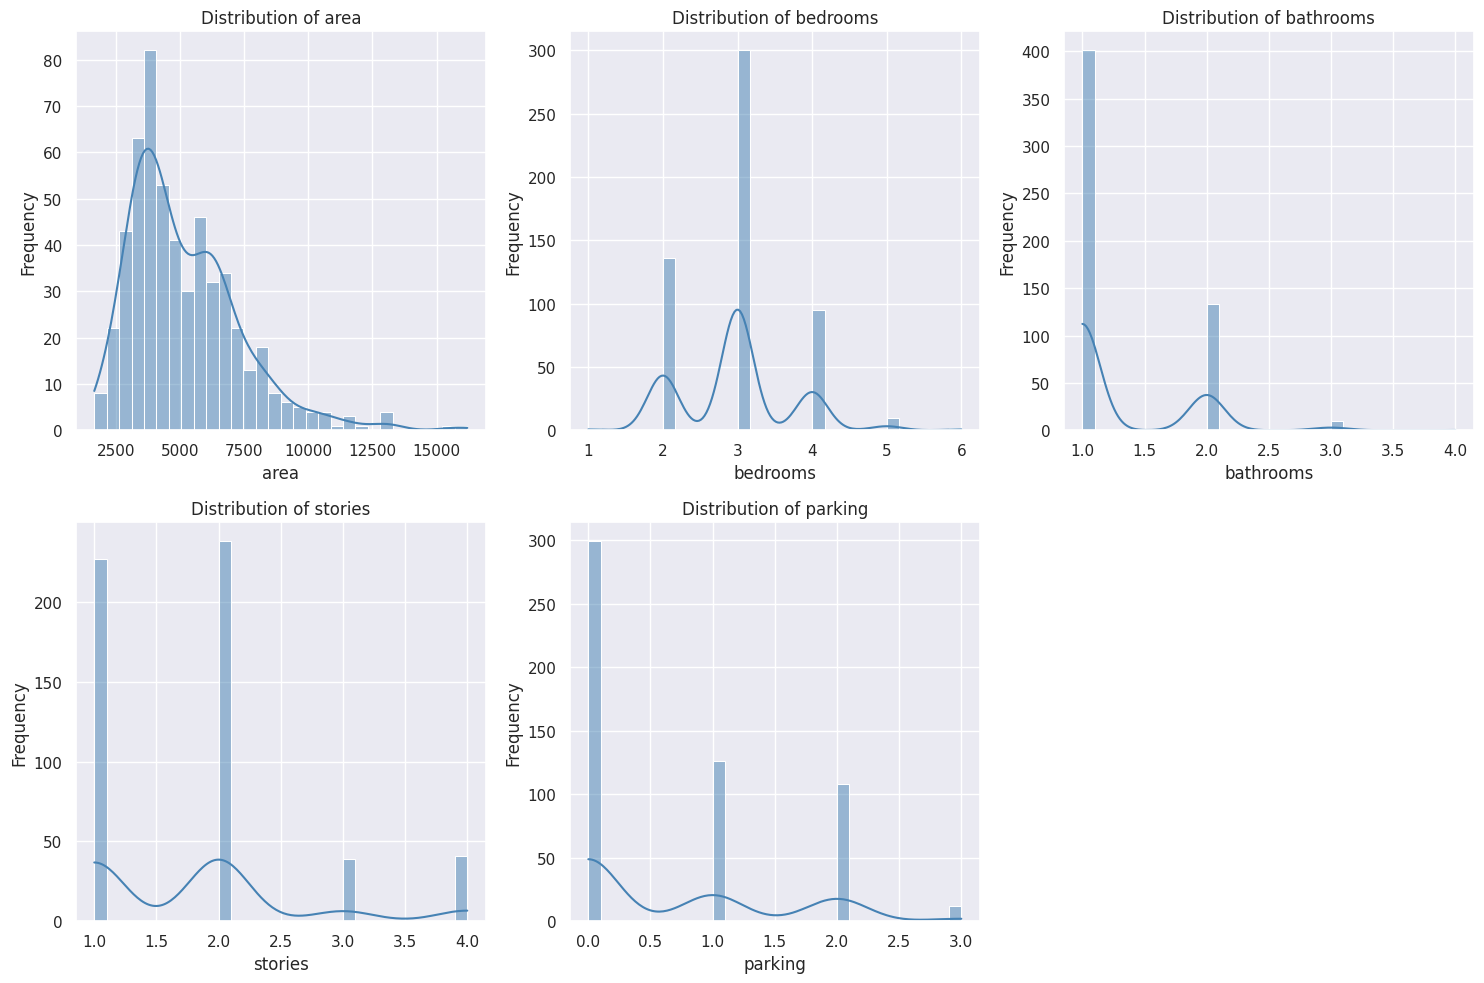

In [ ]:
# Distribution plots for numerical features (excluding target 'price')
numerical_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6.2 Outlier Detection using Boxplots

Boxplots help identify potential outliers and understand the spread of data through quartiles.

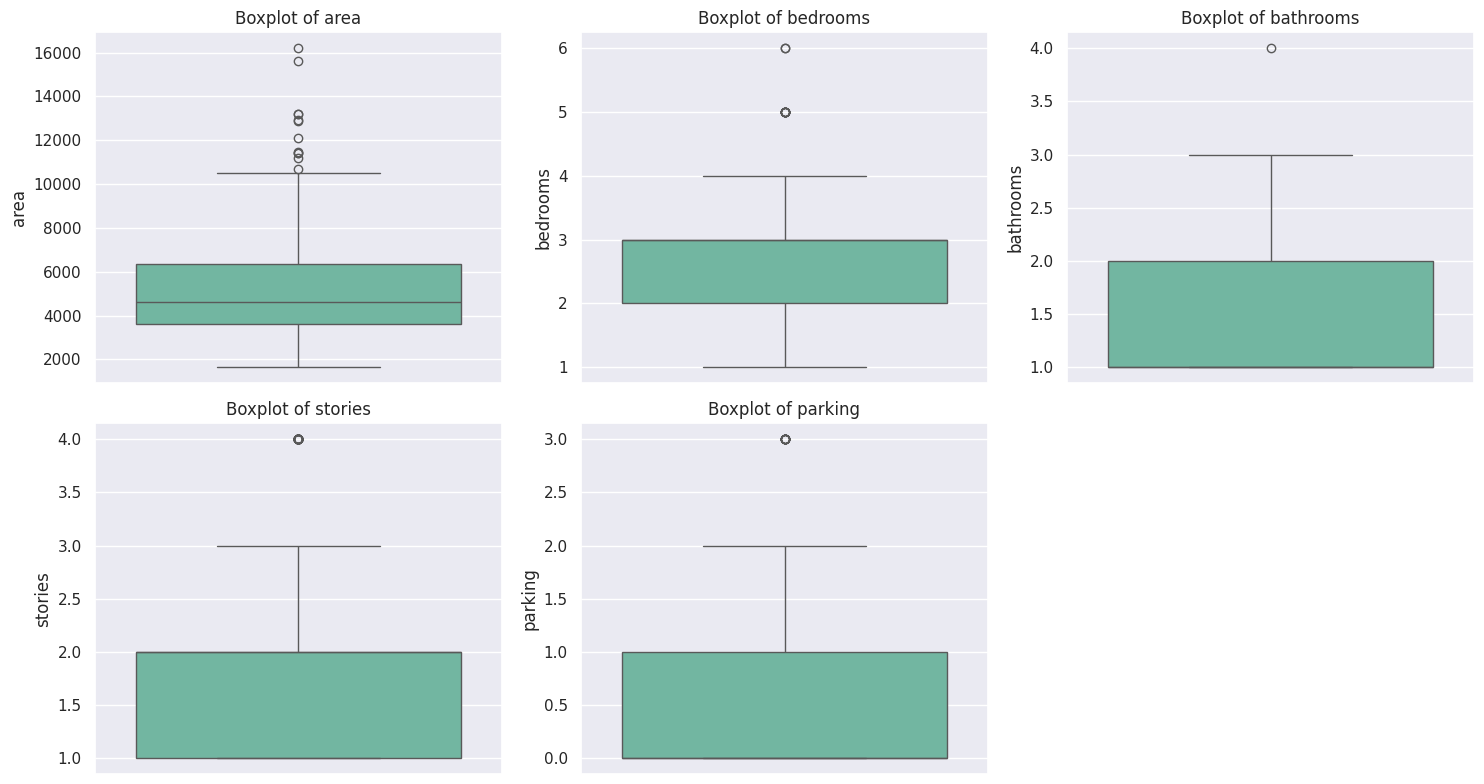

In [ ]:
# Boxplots for numerical features to detect outliers
numerical_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 8))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], palette='Set2')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

## 6.3 Bivariate Analysis - Regression Plots (Before Preprocessing)

Visualizing the linear relationship between each numerical feature and the target variable (price) before any preprocessing.

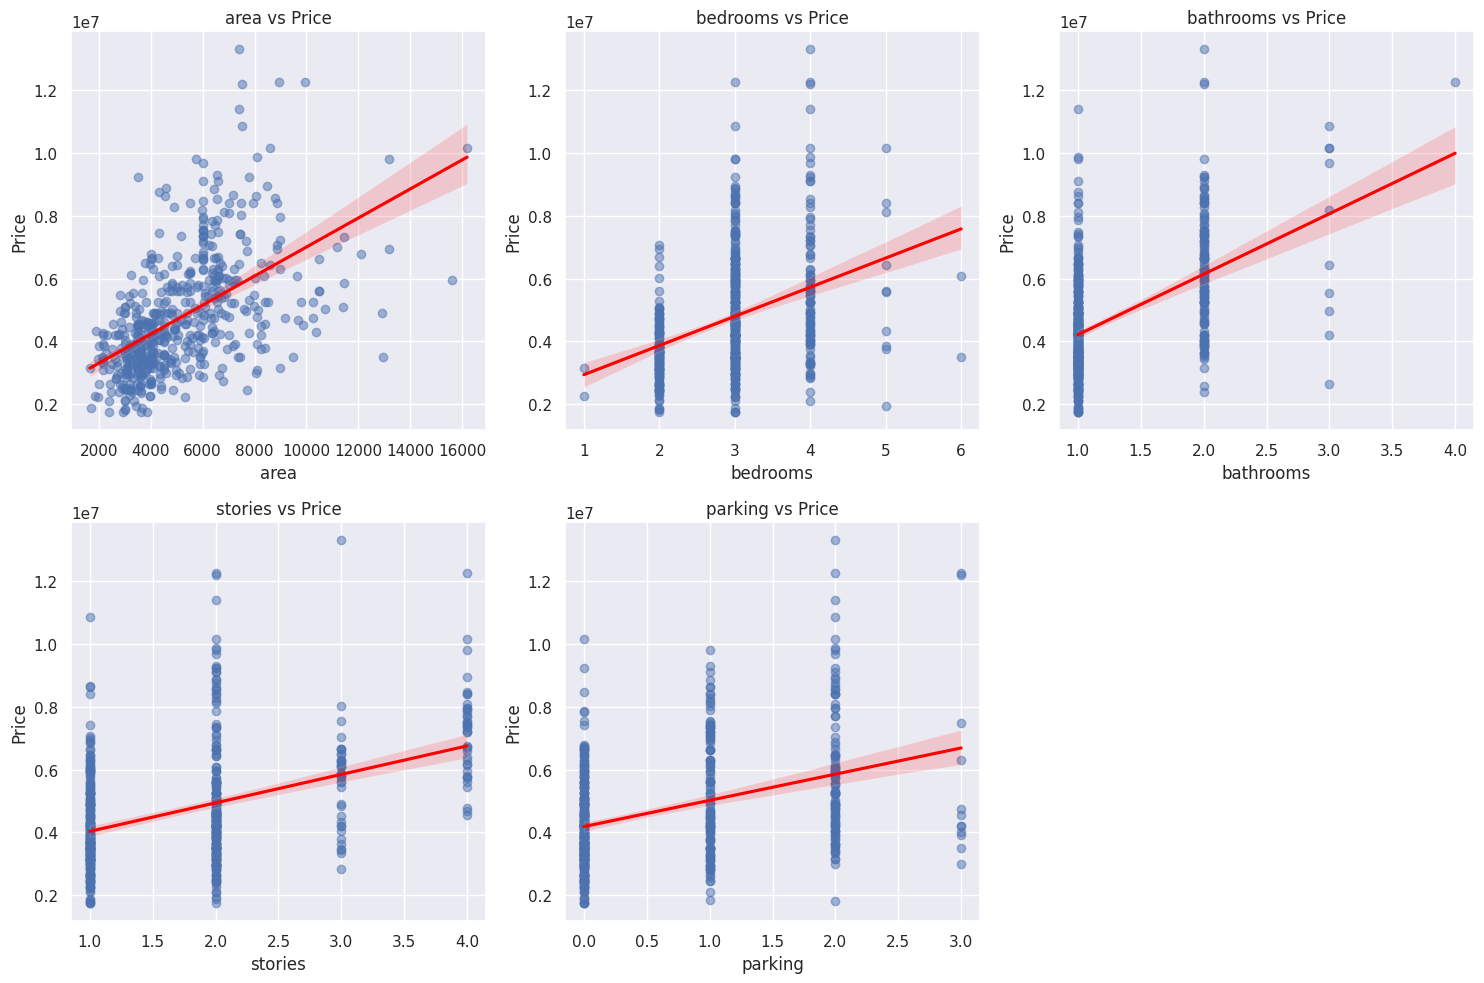

In [ ]:
# Regression plots for numerical features vs price (Before preprocessing)
numerical_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.regplot(x=df[col], y=df['price'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'{col} vs Price')
    plt.xlabel(col)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

## 6.4 Correlation Analysis

Correlation heatmap to identify relationships between numerical features and the target variable.

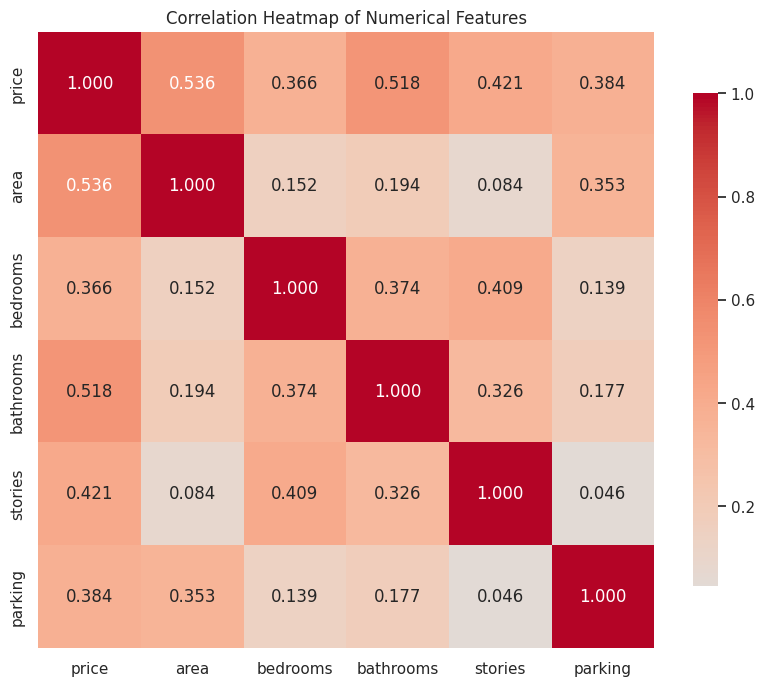

In [ ]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))

# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = numerical_df.corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 6.5 Categorical Variables Analysis

Visualizing the distribution of categorical features using count plots.

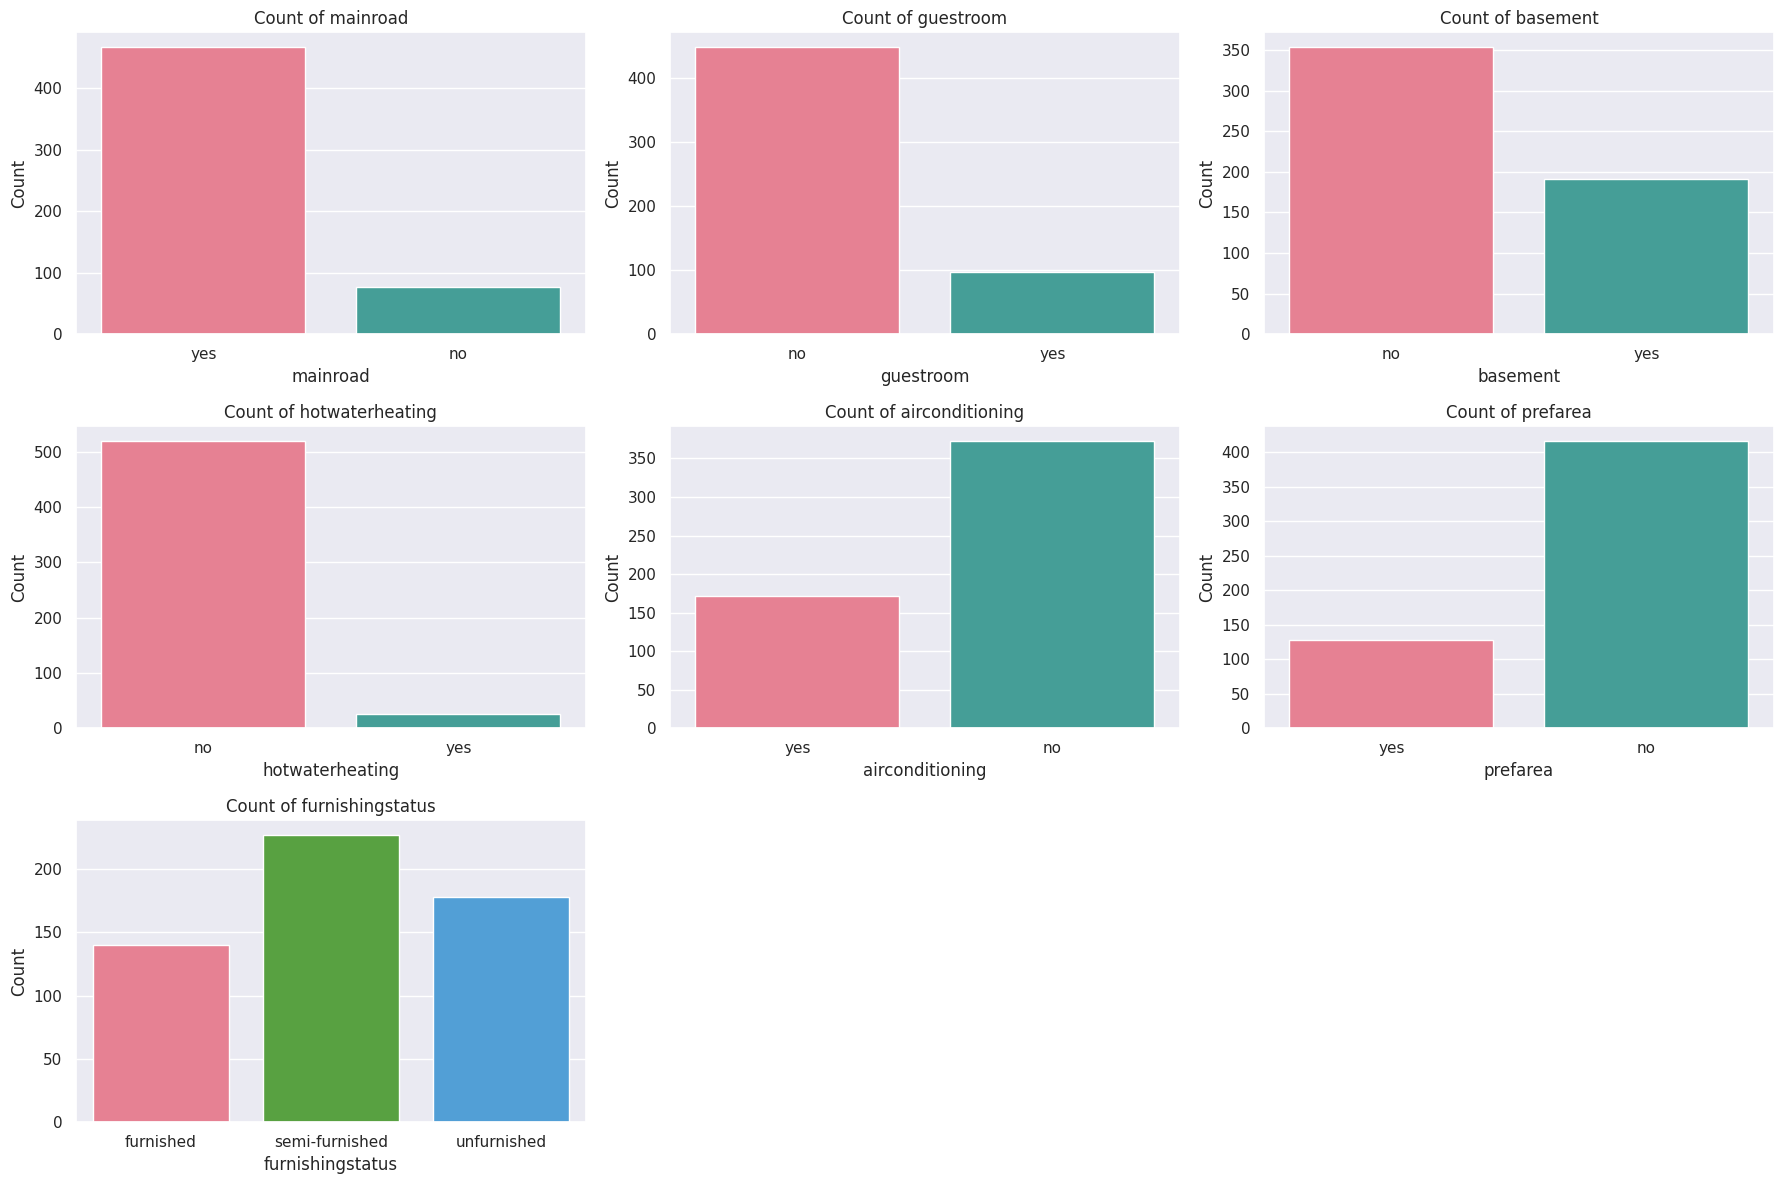

In [ ]:
# Count plots for categorical variables
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=df[col], palette='husl')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 6.6 Categorical Variables vs Price

Analyzing how categorical features impact house prices using boxplots.

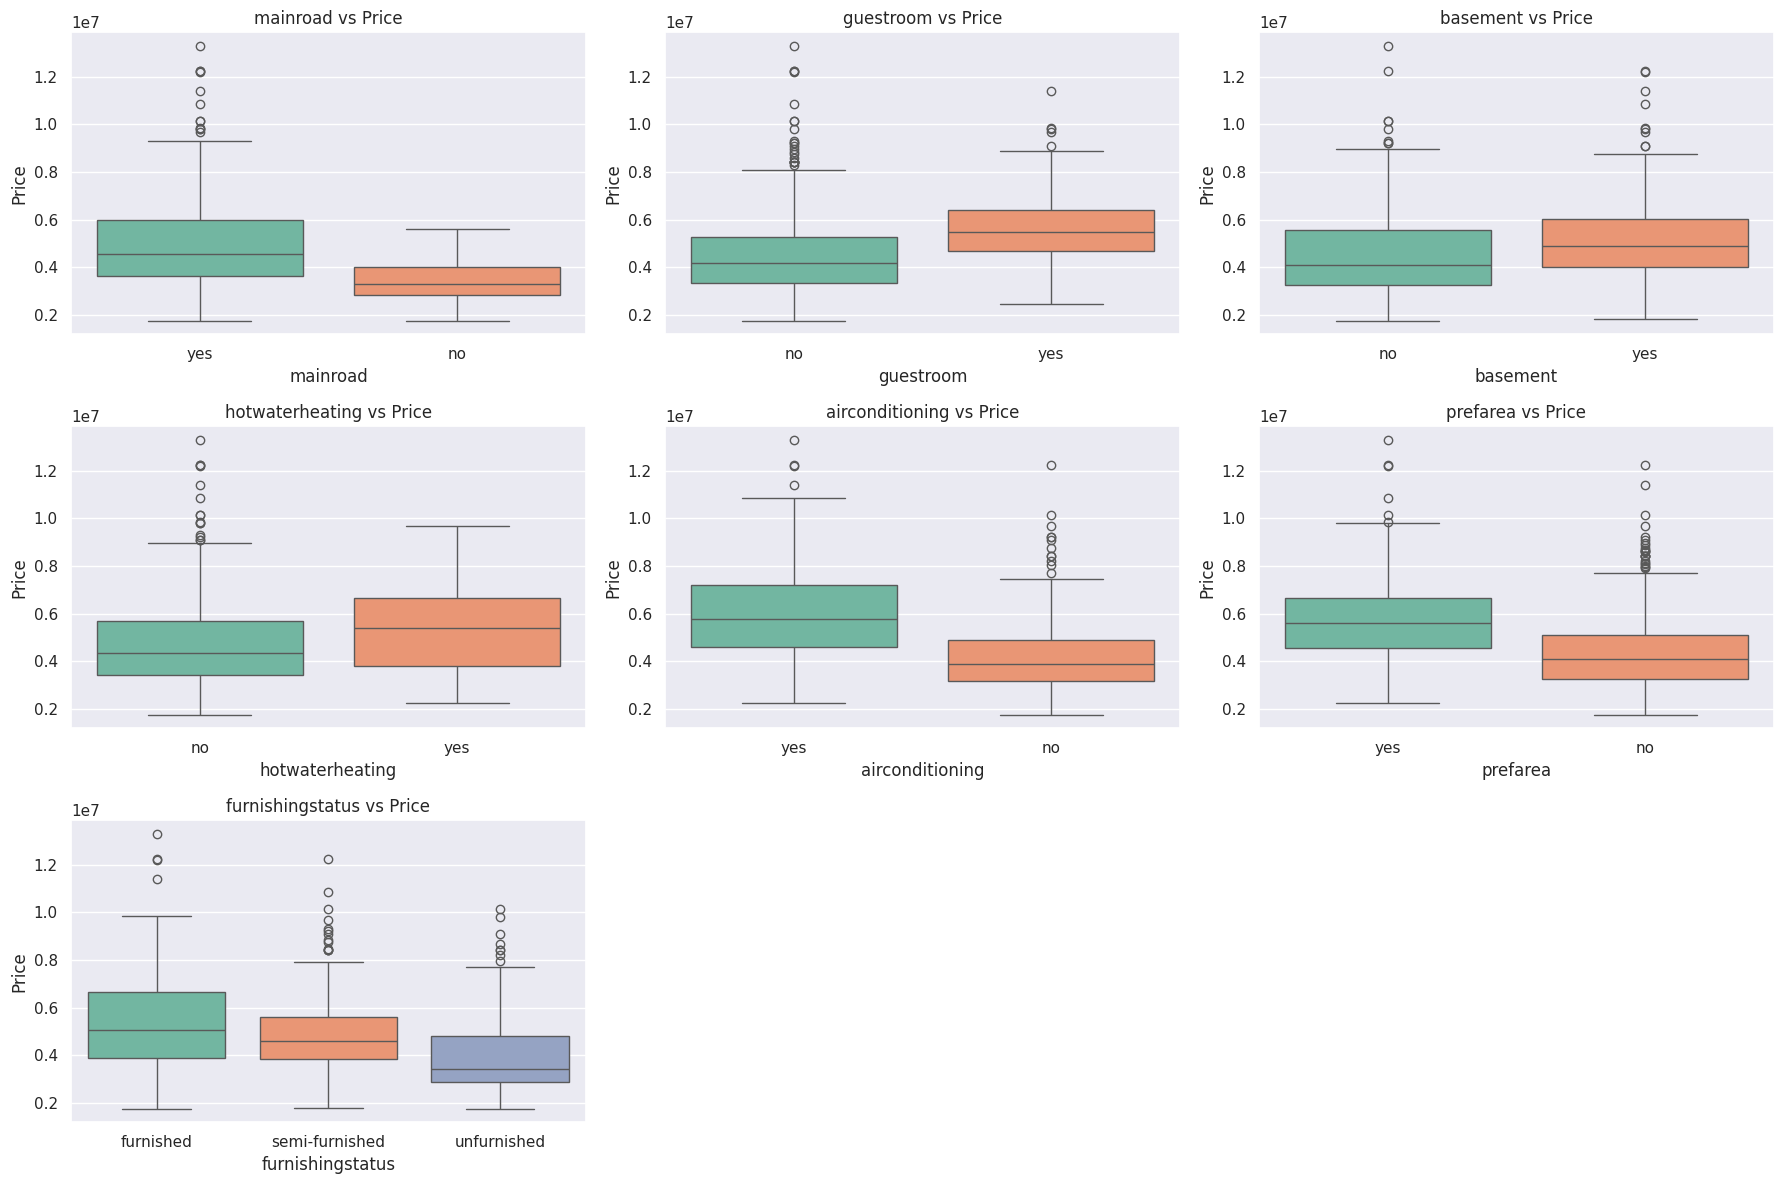

In [ ]:
# Boxplots for categorical variables vs price
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], y=df['price'], palette='Set2')
    plt.title(f'{col} vs Price')
    plt.xlabel(col)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

# Step 7: Data Preprocessing

## 7.1 Encoding Categorical Variables

- Binary categorical variables (yes/no) are encoded to (1/0)
- Multi-class variable (furnishingstatus) is one-hot encoded with drop_first to avoid multicollinearity

In [ ]:
# Create a copy of dataframe for preprocessing
df_processed = df.copy()

# Encode binary categorical variables (yes/no) to (1/0)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

# One-hot encode multi-class categorical variable (furnishingstatus)
df_processed = pd.get_dummies(df_processed, columns=['furnishingstatus'], drop_first=True)

print("Processed Dataset:")
print(df_processed.head())
print("\n" + "="*50)
print("\nData Types after Encoding:")
print(df_processed.dtypes)
print("\n" + "="*50)
print(f"\nShape after encoding: {df_processed.shape}")

Processed Dataset:
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1    

## 7.2 Splitting into Features and Target

Separating the dataset into:
- X: Independent variables (features/predictors)
- y: Dependent variable (target - price)

In [ ]:
# Convert boolean columns to integers (0/1)
df_processed['furnishingstatus_semi-furnished'] = df_processed['furnishingstatus_semi-furnished'].astype(int)
df_processed['furnishingstatus_unfurnished'] = df_processed['furnishingstatus_unfurnished'].astype(int)

# Split into dependent (target) and independent (features) variables
target = 'price'
y = df_processed[[target]]

# All columns except price are features
X = df_processed.drop(target, axis=1)

print("Features (X):")
print(X.head())
print(f"\nShape of X: {X.shape}")
print("\nTarget (y):")
print(y.head())
print(f"\nShape of y: {y.shape}")
print("\nFeature Columns:")
print(list(X.columns))

Features (X):
   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   
3  7500         4          2        2         1          0         1   
4  7420         4          1        2         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  \
0                0                1        2         1   
1                0                1        3         0   
2                0                0        2         1   
3                0                1        3         1   
4                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                                0                             0  
1                                0                             0  
2  

## 7.3 Feature Scaling

Standardizing features to have mean = 0 and standard deviation = 1. This ensures all features contribute equally to the model.

In [ ]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Features (first 5 rows):")
print(X_scaled.head())
print("\n" + "="*50)
print("\nOriginal Features - Descriptive Stats:")
print(X.describe().loc[['mean', 'std']])
print("\n" + "="*50)
print("\nScaled Features - Descriptive Stats:")
print(X_scaled.describe().loc[['mean', 'std']])

Scaled Features (first 5 rows):
       area  bedrooms  bathrooms   stories  mainroad  guestroom  basement  \
0  1.046726  1.403419   1.421812  1.378217  0.405623  -0.465315 -0.734539   
1  1.757010  1.403419   5.405809  2.532024  0.405623  -0.465315 -0.734539   
2  2.218232  0.047278   1.421812  0.224410  0.405623  -0.465315  1.361397   
3  1.083624  1.403419   1.421812  0.224410  0.405623  -0.465315  1.361397   
4  1.046726  1.403419  -0.570187  0.224410  0.405623   2.149083  1.361397   

   hotwaterheating  airconditioning   parking  prefarea  \
0        -0.219265         1.472618  1.517692  1.804941   
1        -0.219265         1.472618  2.679409 -0.554035   
2        -0.219265        -0.679063  1.517692  1.804941   
3        -0.219265         1.472618  2.679409  1.804941   
4        -0.219265         1.472618  1.517692 -0.554035   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                        -0.844888                     -0.696429  
1               

## 7.4 Multicollinearity Check (VIF)

VIF measures how much the variance of a regression coefficient increases due to multicollinearity. VIF > 5 indicates problematic multicollinearity.

The VIF Values Interpretation:
| VIF Value              | Interpretation                |
| ---------------------- | ----------------------------- |
| **All VIF < 5**        | ✅ No multicollinearity issues |
| **Highest VIF = 1.67** | Well below the threshold of 5 |


In [ ]:
# Calculate VIF (Variance Inflation Factor)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]

print("Variance Inflation Factor (VIF):")
print(vif_data.sort_values('VIF', ascending=False))


Variance Inflation Factor (VIF):
                            Feature       VIF
12     furnishingstatus_unfurnished  1.674139
11  furnishingstatus_semi-furnished  1.578233
3                           stories  1.478055
1                          bedrooms  1.369477
0                              area  1.325250
6                          basement  1.323050
2                         bathrooms  1.286621
5                         guestroom  1.212838
9                           parking  1.212837
8                   airconditioning  1.211840
4                          mainroad  1.172728
10                         prefarea  1.149196
7                   hotwaterheating  1.041506


# Step 8: Train-Test Split

Splitting the dataset into training (70%) and testing (30%) sets for model building and evaluation. Since our VIF values < 5 soo we don't need to drop any of the columns as such, and proceed with tran-test split.

In [ ]:
# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("Train-Test Split Summary:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print("\n" + "="*50)
print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Train-Test Split Summary:
X_train shape: (381, 13)
X_test shape:  (164, 13)
y_train shape: (381, 1)
y_test shape:  (164, 1)


Training set: 381 samples (69.9%)
Testing set:  164 samples (30.1%)


# Step 9: Model Training

## Multiple Linear Regression

Training the MLR model on the training dataset to learn the relationship between features and house prices.

In [ ]:
# Initialize and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Extract coefficients and intercept
intercept = model.intercept_[0]
coefficients = model.coef_[0]

# Create coefficient dataframe
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print("="*60)
print("MULTIPLE LINEAR REGRESSION MODEL TRAINED")
print("="*60)
print(f"\nIntercept (β₀): {intercept:,.2f}")
print("\nCoefficients (βᵢ):")
print(coeff_df.to_string(index=False))

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print("• Positive coefficient → Feature increases price")
print("• Negative coefficient → Feature decreases price")
print("• Larger absolute value → Stronger impact on price")

MULTIPLE LINEAR REGRESSION MODEL TRAINED

Intercept (β₀): 4,792,156.29

Coefficients (βᵢ):
                        Feature    Coefficient
                      bathrooms  559614.480930
                           area  549164.541650
                        stories  361644.239779
                airconditioning  318745.845855
                        parking  260916.619069
                       basement  230256.712272
                       prefarea  215853.034064
                       mainroad  142138.056651
                hotwaterheating  128949.744884
                      guestroom  105458.533985
                       bedrooms   59649.504400
furnishingstatus_semi-furnished  -59972.424513
   furnishingstatus_unfurnished -183457.576823

INTERPRETATION:
• Positive coefficient → Feature increases price
• Negative coefficient → Feature decreases price
• Larger absolute value → Stronger impact on price


From the above cell output we can say:
| Feature                           | Coefficient | Interpretation                                        |
| --------------------------------- | ----------- | ----------------------------------------------------- |
| **bathrooms**                     | +559,614    | Most impactful - more bathrooms = higher price ✅      |
| **area**                          | +549,164    | Second most impactful - larger area = higher price ✅  |
| **airconditioning**               | +318,745    | AC adds significant value ✅                           |
| **furnishingstatus\_unfurnished** | -183,457    | Unfurnished = lower price than furnished (baseline) ✅ |


## 9.1 Model Evaluation

Evaluating model performance using R², MSE, RMSE, and MAPE metrics. Since we have trained model lets see how good it is.

In [ ]:
# Predictions on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_test_pred)
accuracy = 100 - (mape * 100)

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"\n📊 R² Score (Training): {train_r2:.4f}")
print(f"📊 R² Score (Testing):  {test_r2:.4f}")
print(f"\n📉 Mean Squared Error (MSE):        {mse:,.2f}")
print(f"📉 Root Mean Squared Error (RMSE):  {rmse:,.2f}")
print(f"📉 Mean Absolute % Error (MAPE):    {mape:.4f}")
print(f"\n✅ Model Accuracy: {accuracy:.2f}%")

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print(f"• R² = {test_r2:.4f}: Model explains {test_r2*100:.2f}% of price variance")
print(f"• RMSE = ₹{rmse:,.0f}: Average prediction error")
print(f"• Accuracy = {accuracy:.2f}%: Overall model accuracy")

MODEL PERFORMANCE METRICS

📊 R² Score (Training): 0.6932
📊 R² Score (Testing):  0.6463

📉 Mean Squared Error (MSE):        1,523,019,469,501.29
📉 Root Mean Squared Error (RMSE):  1,234,106.75
📉 Mean Absolute % Error (MAPE):    0.2120

✅ Model Accuracy: 78.80%

INTERPRETATION:
• R² = 0.6463: Model explains 64.63% of price variance
• RMSE = ₹1,234,107: Average prediction error
• Accuracy = 78.80%: Overall model accuracy


## 9.2 Residual Analysis

Checking if residuals are randomly distributed (good) or show patterns (bad).

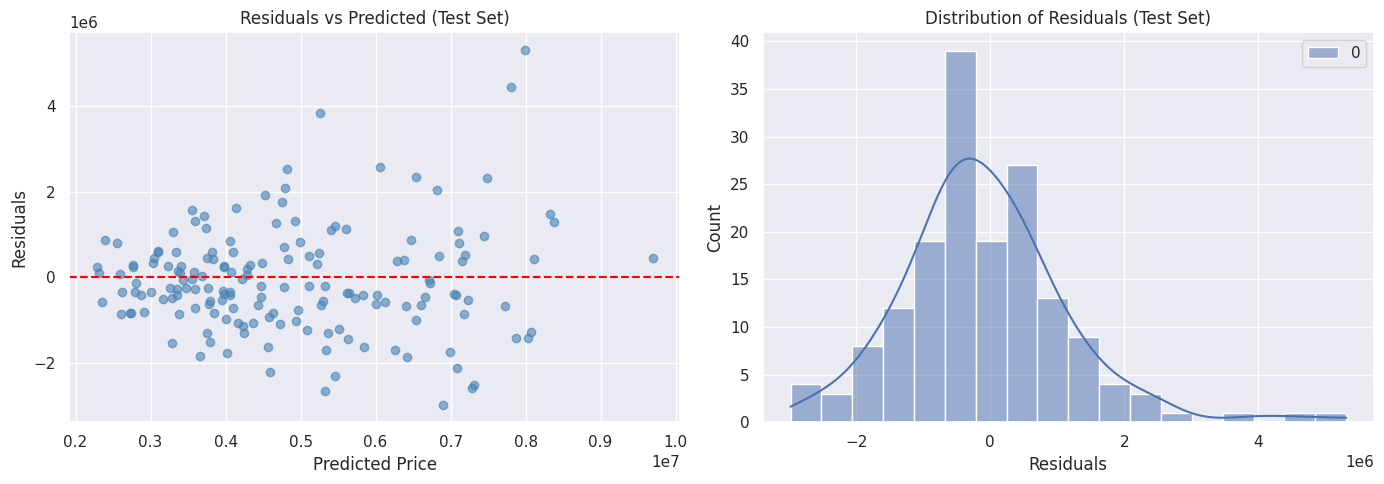

Residual Statistics:
Mean: -84498.42
Std:  1231210.58
Skewness: 0.9300


In [ ]:
# Calculate residuals
train_residuals = y_train.values - y_train_pred
test_residuals = y_test.values - y_test_pred

# Plot residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted (Test)
axes[0].scatter(y_test_pred, test_residuals, alpha=0.6, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted (Test Set)')

# Distribution of residuals
sns.histplot(test_residuals, kde=True, ax=axes[1], color='steelblue')
axes[1].set_xlabel('Residuals')
axes[1].set_title('Distribution of Residuals (Test Set)')

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"Mean: {np.mean(test_residuals):.2f}")
print(f"Std:  {np.std(test_residuals):.2f}")
print(f"Skewness: {pd.Series(test_residuals.flatten()).skew():.4f}")

| Observation                           | Interpretation                                                               |
| ------------------------------------- | ---------------------------------------------------------------------------- |
| **Residuals scattered around zero**   | No strong pattern - linear model is appropriate                            |
| **Slight funnel shape**               | Variance increases with price (heteroscedasticity) - common in price data |
| **Approximately normal distribution** | Residuals are roughly normal                                               |
| **Skewness = 0.93**                   | Slight right skew - some large positive errors                            |


## 9.3 Actual vs Predicted Visualization

Visual comparison of actual prices vs predicted prices. Points closer to the red line indicate better predictions.

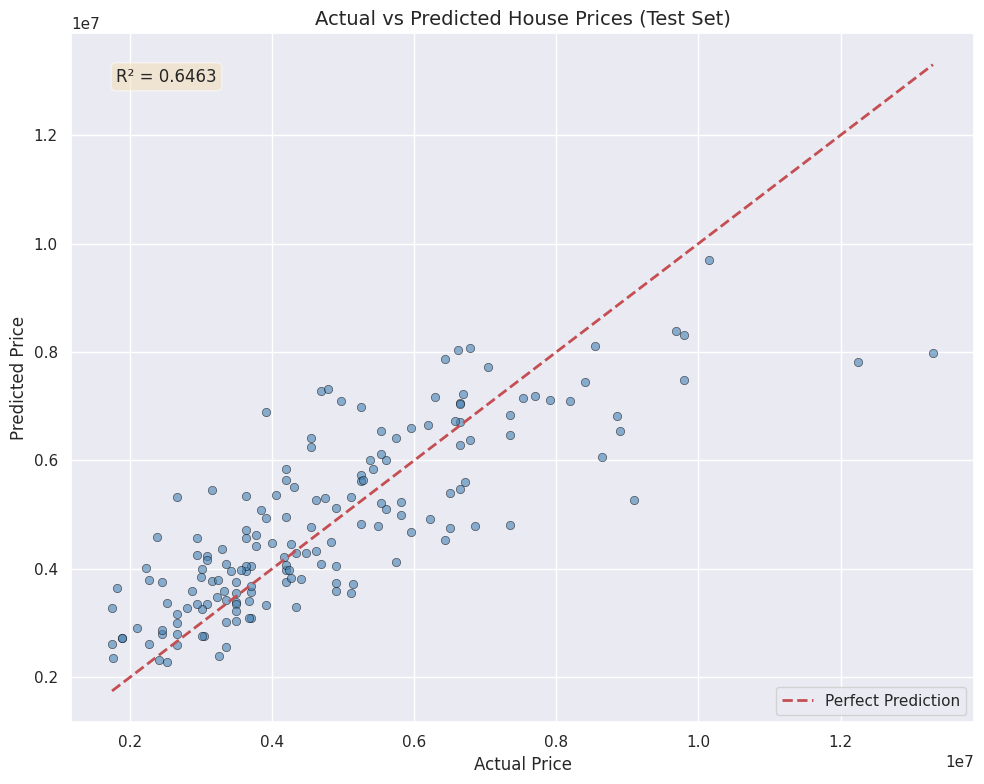

Model explains 64.63% of the variance in house prices.


In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(10, 8))

plt.scatter(y_test, y_test_pred, alpha=0.6, color='steelblue', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.title('Actual vs Predicted House Prices (Test Set)', fontsize=14)
plt.legend()

# Add R² annotation
plt.text(0.05, 0.95, f'R² = {test_r2:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Model explains {test_r2*100:.2f}% of the variance in house prices.")

# **Mathematical Formula Derivation**


## Multiple Linear Regression Equation
### Model Summary
- **Algorithm**: Multiple Linear Regression
- **Training samples**: 381
- **Testing samples**: 164
- **R² Score (Test)**: 0.6463 (64.63% variance explained)
- **RMSE**: ₹1,234,106.75
- **Model Accuracy**: 78.80%


### Mathematical Formula

**Intercept (β₀)**: ₹4,792,156.29

**Number of features (n)**: 13

The final model equation for house price prediction is:

### Complete Equation:
```
Price = 4,792,156.29
+ 559,614.48 × bathrooms
+ 549,164.54 × area
+ 361,644.24 × stories
+ 318,745.85 × airconditioning
+ 260,916.62 × parking
+ 230,256.71 × basement
+ 215,853.03 × prefarea
+ 142,138.06 × mainroad
+ 128,949.74 × hotwaterheating
+ 105,458.53 × guestroom
+ 59,649.50 × bedrooms
- 59,972.42 × furnishingstatus_semi-furnished
- 183,457.58 × furnishingstatus_unfurnished
```



### Simplified Notation:
**Price = 4,792,156 + 559,614·(bath) + 549,165·(area) + 361,644·(sto) + 318,746·(ac) + 260,917·(park) + 230,257·(base) + 215,853·(pref) + 142,138·(main) + 128,950·(hot) + 105,459·(guest) + 59,650·(bed) - 59,972·(semi-furn) - 183,458·(unfurn)**



## Interpretation:

| Rank | Feature | Impact |
|:----:|---------|--------|
| 1 | **bathrooms** | Each additional bathroom increases price by **₹5,59,614** |
| 2 | **area** | Each additional sq.ft increases price by **₹549** |
| 3 | **stories** | Each additional story increases price by **₹3,61,644** |

**Note**: Negative coefficients for furnishing status indicate these are **cheaper than fully furnished** (baseline category).



HOUSE PRICE PREDICTION USING MULTIPLE LINEAR REGRESSION

## Conclusion

Through **EDA**, we identified strong positive correlations between `area`, `bathrooms`, `stories`, and `price`, while `furnishingstatus` also showed clear price distinctions. The **Multiple Linear Regression model** achieved an **R² score of 0.6463** on the test set, explaining approximately 64.63% of the variance in house prices with an **accuracy of 78.80%**. The model revealed that `bathrooms`, `area`, and `airconditioning` are the most significant positive drivers of house price. Residual analysis indicated a generally good fit, with minor heteroscedasticity.